#📌 Extracción

In [1]:
# Cargar los datos directamente desde la API utilizando Python.
import pandas as pd
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
df = pd.read_json(url)

# Convertir los datos a un DataFrame de Pandas para facilitar su manipulación
df_customer = pd.json_normalize(df['customer'])
df_phone    = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account  = pd.json_normalize(df['account'])

df_final = pd.concat([
    df[['customerID', 'Churn']],
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

print("Datos cargados y aplanados con éxito ✔️")
df_final.head()


Datos cargados y aplanados con éxito ✔️


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

Conoce el conjunto de datos

In [2]:
# Mostrar información general del DataFrame
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [3]:
# Ver lista de columnas
print("\nColumnas disponibles:")
print(df_final.columns.tolist())


Columnas disponibles:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


In [4]:
cols_demograficas = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]
cols_servicios = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]
cols_contrato = [
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]
cols_financieras = [
    'Charges.Monthly',
    'Charges.Total'
]


target = ['Churn']

print("Demográficas:", cols_demograficas)
print("Servicios:", cols_servicios)
print("Contrato:", cols_contrato)
print("Financieras:", cols_financieras)
print("Objetivo (Churn):", target)

Demográficas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
Servicios: ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
Contrato: ['Contract', 'PaperlessBilling', 'PaymentMethod']
Financieras: ['Charges.Monthly', 'Charges.Total']
Objetivo (Churn): ['Churn']


Comprobación de incoherencias en los datos


In [5]:
# Valores ausentes por columna
print("Valores ausentes por columna:")
print(df_final.isnull().sum().sort_values(ascending=False))

Valores ausentes por columna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [6]:

# Filas duplicadas
print("\nNúmero de filas duplicadas:", df_final.duplicated().sum())


Número de filas duplicadas: 0


In [7]:
# Tipos de datos de todas las columnas
print("\nTipos de datos por columna:")
print(df_final.dtypes)


Tipos de datos por columna:
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total        object
dtype: object


In [8]:
# Valores únicos de columnas categóricas
print("\nValores únicos en columnas categóricas:")
for col in df_final.select_dtypes(include=['object']).columns:
    print(f"{col}:", df_final[col].unique())


Valores únicos en columnas categóricas:
customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn: ['No' 'Yes' '']
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['Yes' 'No']
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'Yes' 'No phone service']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['Yes' 'No' 'No internet service']
StreamingTV: ['Yes' 'No' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['One year' 'Month-to-month' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
Charges.Total: ['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']


Manejo de inconsistencias

In [9]:
# 1) Eliminar duplicados
df_final = df_final.drop_duplicates()

# 2) Convertir 'Charges.Total' a número (si estaba como texto)
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

# 3) Manejar valores faltantes:
# Para numéricos → completar con mediana
num_cols = df_final.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    df_final[col] = df_final[col].fillna(df_final[col].median())

# Para categóricos → completar con moda (valor más frecuente)
cat_cols = df_final.select_dtypes(include=['object']).columns
for col in cat_cols:
    mode_val = df_final[col].mode()
    if not mode_val.empty:
        df_final[col] = df_final[col].fillna(mode_val[0])

# 4) Normalizar texto en columnas categóricas
# Convertir todo a minúsculas y quitar espacios extra
for col in cat_cols:
    df_final[col] = df_final[col].str.strip().str.lower()

# 5) Verificación de limpieza
print("Valores ausentes después de limpieza:\n", df_final.isnull().sum())
print("\nTipos de datos tras limpieza:\n")
print(df_final.dtypes)

Valores ausentes después de limpieza:
 customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64

Tipos de datos tras limpieza:

customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contra

#📊 Carga y análisis

Análisis Descriptivo

In [10]:
# Estadísticas descriptivas para todas las columnas numéricas
print("Estadísticas descriptivas de variables numéricas:")
print(df_final[['tenure', 'Charges.Monthly', 'Charges.Total']].describe())

# También puedes obtener estadísticas personalizadas si quieres
print("\nMediana de tenure:", df_final['tenure'].median())
print("Media de Charges.Monthly:", df_final['Charges.Monthly'].mean())
print("Desviación estándar de Charges.Total:", df_final['Charges.Total'].std())


Estadísticas descriptivas de variables numéricas:
            tenure  Charges.Monthly  Charges.Total
count  7267.000000      7267.000000    7267.000000
mean     32.346498        64.720098    2279.287581
std      24.571773        30.129572    2267.178963
min       0.000000        18.250000      18.800000
25%       9.000000        35.425000     401.400000
50%      29.000000        70.300000    1391.000000
75%      55.000000        89.875000    3778.525000
max      72.000000       118.750000    8684.800000

Mediana de tenure: 29.0
Media de Charges.Monthly: 64.72009770194028
Desviación estándar de Charges.Total: 2267.1789632993236


Distribución de evasión (churn)

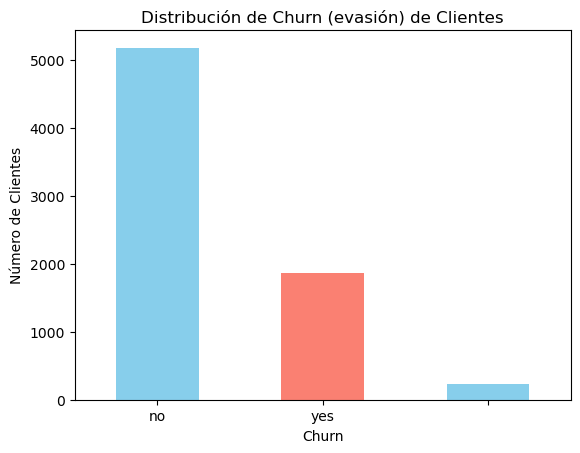

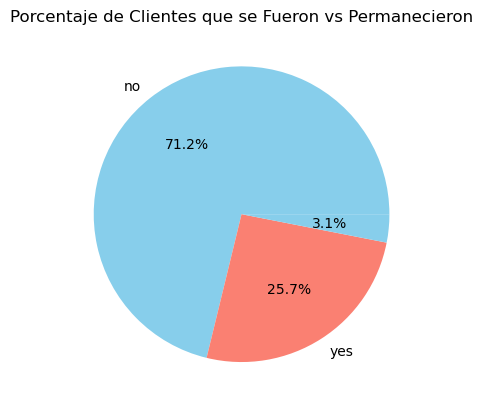

In [11]:
import matplotlib.pyplot as plt

# Conteo de churn
churn_counts = df_final['Churn'].value_counts()

# Gráfico de barras simple
churn_counts.plot(kind='bar', color=['skyblue','salmon'])
plt.title("Distribución de Churn (evasión) de Clientes")
plt.xlabel("Churn")
plt.ylabel("Número de Clientes")
plt.xticks(rotation=0)
plt.show()

# También un gráfico circular (pie)
churn_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue','salmon'])
plt.title("Porcentaje de Clientes que se Fueron vs Permanecieron")
plt.ylabel("")
plt.show()


Recuento de evasión por variables categóricas

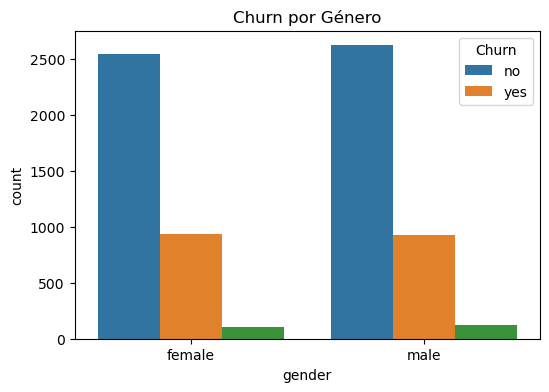

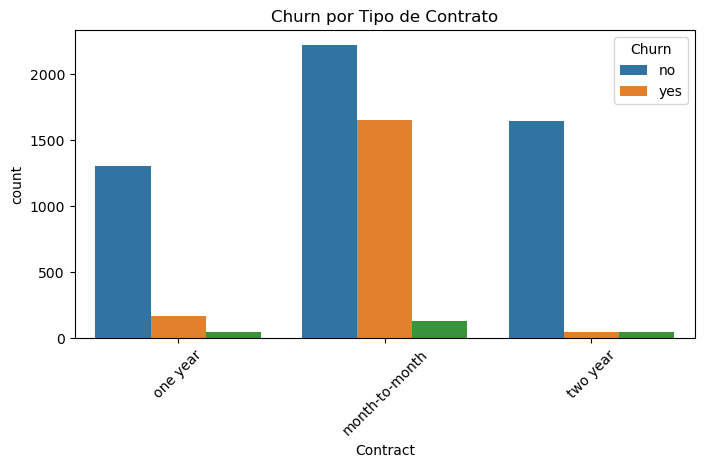

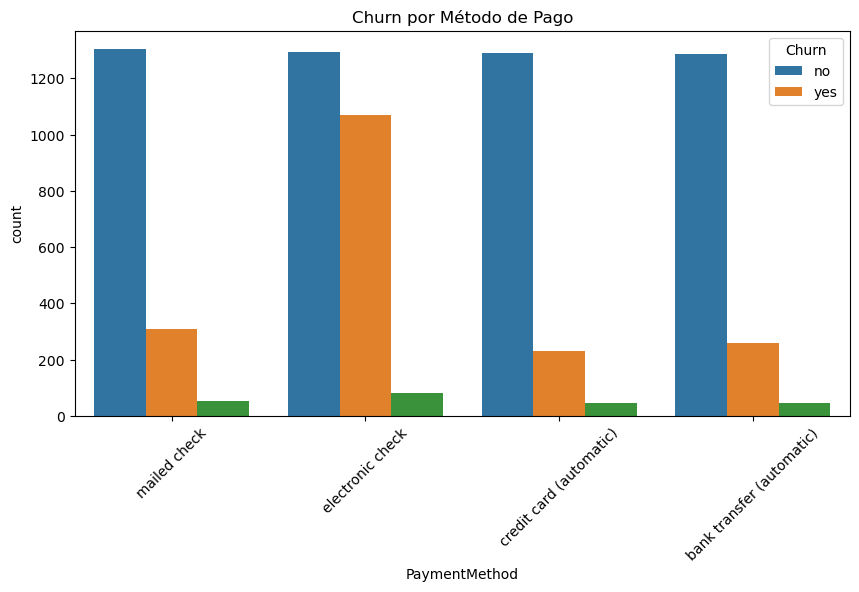

In [12]:
import seaborn as sns

# Evasión por género
plt.figure(figsize=(6,4))
sns.countplot(data=df_final, x='gender', hue='Churn')
plt.title("Churn por Género")
plt.show()

# Evasión por tipo de contrato
plt.figure(figsize=(8,4))
sns.countplot(data=df_final, x='Contract', hue='Churn')
plt.title("Churn por Tipo de Contrato")
plt.xticks(rotation=45)
plt.show()

# Evasión por método de pago
plt.figure(figsize=(10,5))
sns.countplot(data=df_final, x='PaymentMethod', hue='Churn')
plt.title("Churn por Método de Pago")
plt.xticks(rotation=45)
plt.show()


Recuento de evasión por variables numéricas

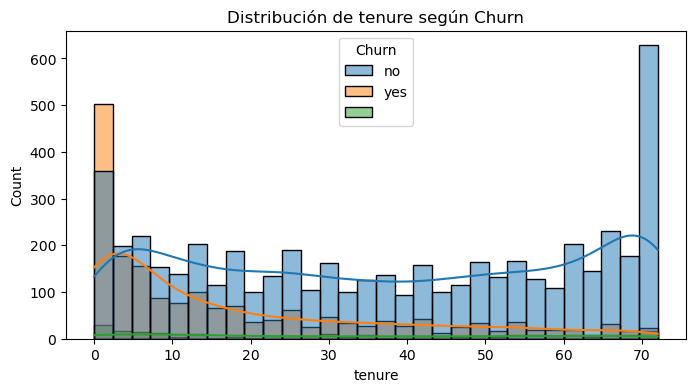

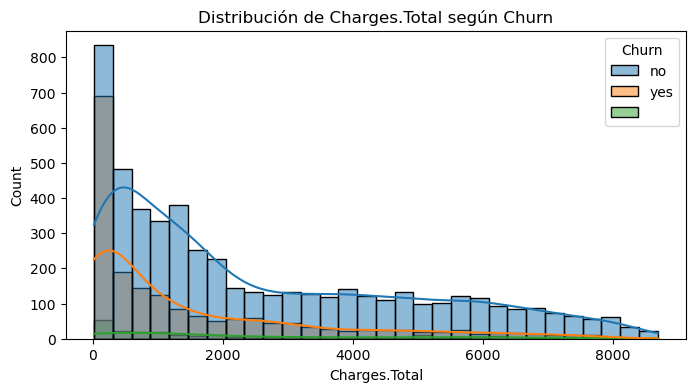

In [13]:
# Histograma de tenure por churn
plt.figure(figsize=(8,4))
sns.histplot(data=df_final, x='tenure', hue='Churn', kde=True, bins=30)
plt.title("Distribución de tenure según Churn")
plt.show()

# Histograma de Charges.Total por churn
plt.figure(figsize=(8,4))
sns.histplot(data=df_final, x='Charges.Total', hue='Churn', kde=True, bins=30)
plt.title("Distribución de Charges.Total según Churn")
plt.show()


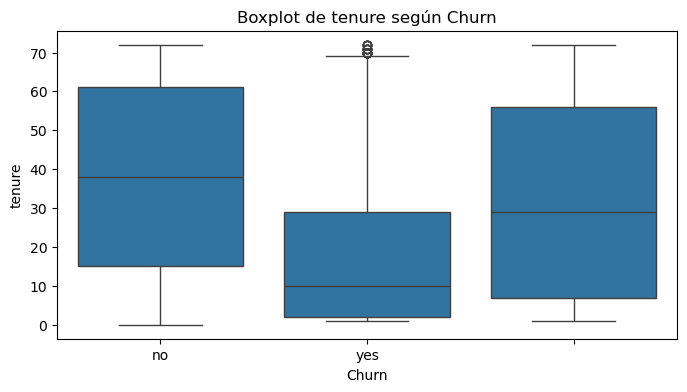

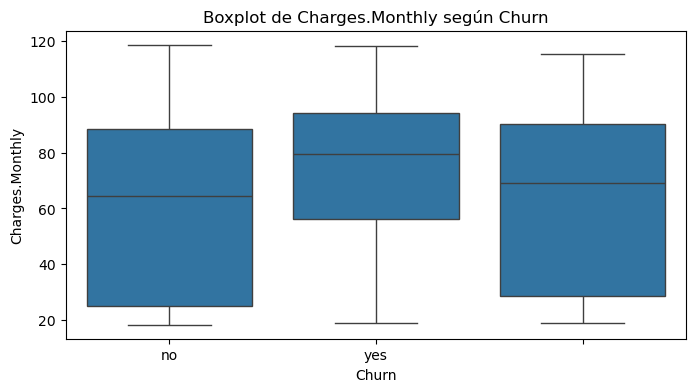

In [14]:
# Boxplot tenure
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn', y='tenure', data=df_final)
plt.title("Boxplot de tenure según Churn")
plt.show()

# Boxplot Charges.Monthly
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn', y='Charges.Monthly', data=df_final)
plt.title("Boxplot de Charges.Monthly según Churn")
plt.show()


#📄Informe final

**Introducción**

En este proyecto se analiza la evasión de clientes (churn) de la empresa Telecom X. El objetivo es entender qué factores están asociados con la pérdida de clientes y extraer patrones que puedan ayudar a reducir la evasión, mejorando la toma de decisiones estratégicas y la fidelización.

**Limpieza y Tratamiento de Datos**

Tras cargar los datos, examinamos la estructura y los tipos de cada columna. Se identificaron valores inconsistentes en texto y tipos de datos incorrectos (por ejemplo, Charges.Total como texto). Se aplicaron transformaciones para asegurar que los datos estén completos, sin duplicados y con categorías homogéneas antes de proceder con el análisis.

**Análisis Exploratorio de Datos**

* Análisis Descriptivo: Se calcularon estadísticas descriptivas de variables clave como tenure, charges.monthly y charges.total para comprender su distribución y presencia de posibles valores extremos. Esto ayuda a identificar patrones de comportamiento entre clientes que dejaron la empresa vs. los que permanecieron.

* Distribución de evasión: El gráfico de barras revela la proporción de clientes que han cancelado el servicio (churn) frente a los que permanecen, permitiendo observar el peso relativo de la evasión en el total.

* Recuento por variables categóricas: Al analizar churn por tipo de contrato, se observa que los clientes con contrato mes a mes presentan mayor cancelación que aquellos con contratos anuales o de largo plazo.

* Relación con variables numéricas: El histograma de charges.total sugiere que clientes con menor gasto acumulado tienden más a abandonar el servicio, mientras que clientes con mayor antigüedad muestran patrones diferenciados.



**Conclusiones e Insights**

El análisis revela que el tipo de contrato y el nivel de gasto son factores relevantes asociados a la retención de clientes. La distribución de churn confirma que ciertos grupos presentan mayores tasas de abandono.

**Recomendaciones**

* Implementar programas de fidelización para clientes con contrato mes a mes.
* Ofrecer descuentos o beneficios adicionales a clientes con bajo charges.total.
* Revisar políticas de precio o paquetes para clientes con alto riesgo de churn.
* Desarrollo de ofertas personalizadas según características demográficas o de uso del servicio.